In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
class RandomFlip(object):
    def __init__(self, p_horizontal=0.5, p_vertical=0.5):
        self.p_horizontal = p_horizontal
        self.p_vertical = p_vertical

    def __flipHorizontal(self, image_np, label):    
        if random.random() > self.p_horizontal:
            return image_np, label
        
        flipped_image = np.ascontiguousarray(image_np[:, ::-1])
        if flipped_image.size == 0 or label.numel() == 0:
            return image_np, label
        
        bbox = label.view(-1).clone()
        bbox[1] = 1.0 - bbox[1]  # Oglindire pe X
        
        return flipped_image, bbox
    
    def __flipVertical(self, image_np, label):
        if random.random() > self.p_vertical:
            return image_np, label
        
        flipped_image = np.ascontiguousarray(image_np[::-1, :])
        if flipped_image.size == 0 or label.numel() == 0:
            return image_np, label
        
        bbox = label.view(-1).clone()
        bbox[2] = 1.0 - bbox[2]  # Oglindire pe Y
        
        return flipped_image, bbox

    def __call__(self, image, label):
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            return image, label

        lbl = label.clone() if isinstance(label, torch.Tensor) else torch.as_tensor(label, dtype=torch.float32)

        flipped_image, flipped_lbl = self.__flipHorizontal(image_np, lbl)
        flipped_image, flipped_lbl = self.__flipVertical(flipped_image, flipped_lbl)

        image_out = Image.fromarray(flipped_image) if is_pil else flipped_image
        return image_out, flipped_lbl

In [3]:
import cv2

class RandomRotate(object):
    def __init__(self, max_angle=30, min_angle=-30, p=0.5):
        self.max_angle = max_angle
        self.min_angle = min_angle
        self.p = p

    def __call__(self, image, label):
        if random.random() > self.p:
            return image, label
        
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            return image, label

        h, w, _ = image_np.shape
        angle = random.uniform(self.min_angle, self.max_angle)

        center = (w / 2.0, h / 2.0)
        rot_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_image = cv2.warpAffine(image_np, rot_matrix, (w, h), flags=cv2.INTER_LINEAR)

        if rotated_image.size == 0:
            return image, label
        
        bbox = label.view(-1).clone() if isinstance(label, torch.Tensor) else torch.as_tensor(label, dtype=torch.float32)
        cls, cx, cy, bw, bh = bbox.tolist()
        top = (cy - bh / 2.0) * h
        left = (cx - bw / 2.0) * w
        bottom = (cy + bh / 2.0) * h
        right = (cx + bw / 2.0) * w

        corners = np.array([[left, top], [right, top], [right, bottom], [left, bottom]])

        rotated_corners = cv2.transform(np.array([corners]), rot_matrix)[0]

        newW = np.max(rotated_corners[:, 0]) - np.min(rotated_corners[:, 0])
        newH = np.max(rotated_corners[:, 1]) - np.min(rotated_corners[:, 1])
        newCx = np.mean(rotated_corners[:, 0])
        newCy = np.mean(rotated_corners[:, 1])

        new_bbox = torch.tensor([cls, newCx, newCy, newW, newH
        ], dtype=torch.float32) / torch.tensor([1, w, h, w, h], dtype=torch.float32)
        

        image_out = Image.fromarray(rotated_image) if is_pil else rotated_image
        return image_out, new_bbox.view(-1)

In [4]:
class RandomGaussianBlur(object):
    def __init__(self, kernel_size=5, p=0.5):
        self.kernel_size = kernel_size
        self.p = p

    def __call__(self, image, label):
        if random.random() > self.p:
            return image, label
        
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            return image, label

        blurred_image = cv2.GaussianBlur(image_np, (self.kernel_size, self.kernel_size), 0)

        if blurred_image.size == 0:
            return image, label

        image_out = Image.fromarray(blurred_image) if is_pil else blurred_image
        return image_out, label

In [5]:
class RandomMotionBlur(object):
    def __init__(self, kernel_size=5, p=0.5):
        self.kernel_size = kernel_size
        self.p = p

    def __call__(self, image, label):
        if random.random() > self.p:
            return image, label
        
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            print("Image is not 3-channel, skipping motion blur.")
            return image, label

        kernel_motion_blur = np.zeros((self.kernel_size, self.kernel_size))
        kernel_motion_blur[int((self.kernel_size - 1) / 2), :] = np.ones(self.kernel_size)
        kernel_motion_blur /= self.kernel_size

        blurred_image = cv2.filter2D(image_np, -1, kernel_motion_blur)

        if blurred_image.size == 0:
            print("Blurred image is empty, skipping motion blur.")
            return image, label

        image_out = Image.fromarray(blurred_image) if is_pil else blurred_image
        return image_out, label

In [6]:
import random

import numpy as np


class RandomExpand(object):
    def __init__(self, mean=(0.485, 0.456, 0.406), max_ratio=4.0, p=0.5):
        self.mean = mean
        self.max_ratio = max_ratio
        self.p = p

    def __call__(self, image, label):
        # Aplicam transformarea doar cu o anumita probabilitate (p)
        if random.random() > self.p:
            return image, label

        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image

        if image_np.ndim != 3:
            return image, label

        height, width, depth = image_np.shape
        ratio = random.uniform(1, self.max_ratio)
        left = random.uniform(0, width * ratio - width)
        top = random.uniform(0, height * ratio - height)

        # Pentru imagini uint8, media [0,1] trebuie scalata la [0,255]
        fill_value = np.array(0, dtype=np.float32)
        if image_np.dtype == np.uint8 and fill_value.max() <= 1.0:
            fill_value = (fill_value * 255.0).astype(np.uint8)
        else:
            fill_value = fill_value.astype(image_np.dtype, copy=False)

        # Cream canvas-ul nou (marit)
        expand_image = np.zeros(
            (int(height * ratio), int(width * ratio), depth),
            dtype=image_np.dtype
        )
        expand_image[:, :, :] = fill_value

        # Plasam imaginea originala in noul canvas
        expand_image[int(top):int(top + height),
                     int(left):int(left + width)] = image_np

        # Ajustam coordonatele bounding box-urilor normalizate [cls, xmin, ymin, xmax, ymax]
        bbox = label.view(-1).clone() if isinstance(label, torch.Tensor) else torch.as_tensor(label, dtype=torch.float32)
        cls, cx, cy, bw, bh = bbox.tolist()
        new_cx = (cx * width + left) / (width * ratio)
        new_cy = (cy * height + top) / (height * ratio)
        new_bw = bw / ratio
        new_bh = bh / ratio

        new_bbox = torch.tensor([cls, new_cx, new_cy, new_bw, new_bh], dtype=torch.float32)

        image_out = Image.fromarray(expand_image) if is_pil else expand_image
        return image_out, new_bbox

In [7]:
from pathlib import Path
import torch
from torch.utils.data import Dataset
from PIL import Image
import random

class YoloDataset(Dataset):
    def __init__(self, images_dir: Path, labels_dir: Path, transform=None):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.transform = transform

        allowed_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        self.samples = []

        for image_path in self.images_dir.iterdir():
            if image_path.suffix.lower() not in allowed_ext:
                continue

            label_path = self.labels_dir / f"{image_path.stem}.txt"
            if label_path.exists():
                self.samples.append((image_path, label_path))

        if not self.samples:
            raise RuntimeError(f"Nu exista perechi imagine-label in {self.images_dir}")

        self.randomFlip = RandomFlip(p_horizontal=0.5, p_vertical=0.5)
        self.randomRotate = RandomRotate(max_angle=30, min_angle=-30, p=0.5)
        self.randomMotionBlur = RandomMotionBlur(kernel_size=3, p=0.5)
        self.randomGaussianBlur = RandomGaussianBlur(kernel_size=5, p=0.5)
        self.randomExpand = RandomExpand(mean=(0.485, 0.456, 0.406), max_ratio=4.0, p=0.5)
        
    def __len__(self):
        return len(self.samples)
    
    def _read_label(self, label_path: Path):
        with open(label_path, 'r') as f:
            features = f.readline().strip().split(" ")

        cls = int(features[0])
        bbox = [float(point) for point in features[1:5]]

        label = [cls] + bbox
        
        return torch.tensor(label, dtype=torch.float32)
    
    
    def __getitem__(self, idx):
        image_path, label_path = self.samples[idx]

        label = self._read_label(label_path)
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image, label = self.randomMotionBlur(image, label)
            image, label = self.randomGaussianBlur(image, label)
            image, label = self.randomFlip(image, label)
            image, label = self.randomRotate(image, label)
            image, label = self.randomExpand(image, label)
            image = self.transform(image)

        # Returnăm direct, fără să mai tăiem nimic la final!
        unsqueze_label = label.view(1, -1)
        return image, unsqueze_label
        
    
from torchvision import transforms

image_size = 300


transform = transforms.Compose([
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Face valorile [-2, 2]
])

trainDataset = YoloDataset("dataset/hand-keypoints/images/train",
                        "dataset/hand-keypoints/labels/train", transform=transform)
                        
testDataset = YoloDataset("dataset/hand-keypoints/images/val",
                        "dataset/hand-keypoints/labels/val", transform=transform)

print(f"Numar de imagini pentru antrenare: {len(trainDataset)}")
print(f"Numar de imagini pentru testare: {len(testDataset)}")

print(f"shape label: {trainDataset[0][1].shape}")

Numar de imagini pentru antrenare: 18776
Numar de imagini pentru testare: 7992
shape label: torch.Size([1, 5])


bbox corners: [0.0, 0.4136597514152527, 0.5937783122062683, 0.3823246359825134, 0.4469332993030548]


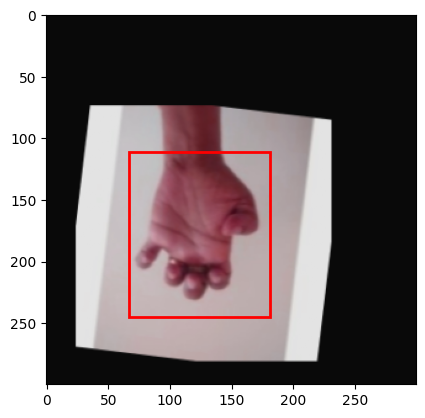

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

randomIndex = random.randint(0, len(testDataset) - 1)
img_tensor, label_tensor = testDataset[randomIndex]
# print(label_tensor)

img = img_tensor.permute(1, 2, 0).numpy() 

fig, ax = plt.subplots(1)
ax.imshow(img)

h, w, _ = img.shape


bbox = label_tensor[0].detach().cpu().numpy().reshape(-1)
cls, cx, cy, bw, bh = bbox.tolist()

# x_min = (cx - bw/2) * w
# y_min = (cy - bh/2) * h
# x_max = (cx + bw/2) * w
# y_max = (cy + bh/2) * h
# print(f"bbox corners: ({x_min}, {y_min}), ({x_max}, {y_max})")

box = patches.Rectangle(((cx - bw/2 )* w, (cy - bh/2) * h), bw * w, bh * h, linewidth=2, edgecolor='r', facecolor='none')
print(f"bbox corners: {bbox.tolist()}")
ax.add_patch(box)


plt.show()

In [9]:
from torch.utils.data import DataLoader

batchSize = 16

def collate_fn(batch):
    return tuple(zip(*batch))

trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True, collate_fn=collate_fn)
testLoader = DataLoader(testDataset, batch_size=batchSize, shuffle=False, collate_fn=collate_fn)

In [10]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))


def evaluate_model(net: nn.Module, test_loader: DataLoader, loss_fn: nn.Module):
    net.eval() 
    total_loss = 0.0
    batches = 0

    with torch.no_grad():
        for test_images, test_labels in test_loader:

            test_images = torch.stack(test_images).to(device)

            test_labels = [l.to(device) for l in test_labels]

            with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
                out = net(test_images)
                loss = loss_fn(out, test_labels)

            total_loss += loss.item()
            batches += 1

    
    return total_loss / batches if batches > 0 else 0


def train_fn(epochs: int, train_loader: DataLoader, test_loader: DataLoader,
             net: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
             start_epoch: int = 0, wait_epochs: int = 5):
    bestValLoss = float('inf')
    lazy = 0
    last_val_loss = 0

    for e in range(start_epoch, epochs):
        net.train() 
        train_loss_acumulat = 0.0

        for images, labels in train_loader:
            
            images = torch.stack(images).to(device)
            labels = [l.to(device) for l in labels]

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
                out = net(images)
                loss = loss_fn(out, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss_acumulat += loss.item()

        avg_train_loss = train_loss_acumulat / len(train_loader)
        val_loss = evaluate_model(net, test_loader, loss_fn)

        if val_loss < bestValLoss:
            bestValLoss = val_loss
            torch.save(net.state_dict(), f'bbox3_epoch{e + 1}.pth')
            lazy = 0
        else:
            lazy += 1
            if lazy >= wait_epochs:
                # reduce learning rate by half
                for pg in optimizer.param_groups:
                    pg['lr'] = pg.get('lr', 0) * 0.5
                print(f"Reducing learning rate by 2 la epoca {e + 1}. New LR: {optimizer.param_groups[0]['lr']:.6f}")
                lazy = 0

        # if abs(val_loss - last_val_loss) <= 0.003:
        #     # reduce learning rate by half
        #     lazy += 1
            
        #     if lazy >= wait_epochs:
        #         for pg in optimizer.param_groups:
        #             pg['lr'] = pg.get('lr', 0) * 0.5
        #         print(f"Reducing learning rate by 2 la epoca {e + 1} din cauza stagnarii. New LR: {optimizer.param_groups[0]['lr']:.6f}")
        #         lazy = 0
        # else:
        #     lazy = 0
        # last_val_loss = val_loss

        print(f"Epoca {e + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Validation Loss: {val_loss:.4f}")



In [16]:
from model2 import HandDetectionNetwork
import os
import torch

net = HandDetectionNetwork(6)

# checkpoint_path = "bbox2_epoch10.pth"
# if os.path.exists(checkpoint_path):
#     net.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
#     print(f"Loaded checkpoint: {checkpoint_path}")
# else:
#     print(f"Checkpoint not found: {checkpoint_path}. Using randomly initialized weights.")

net.to(device)

HandDetectionNetwork(
  (backbone): ModifiedMobileNet(
    (img_6): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): ConvBlock(
        (convBlock): Sequential(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU(inplace=True)
        )
      )
      (4): ConvBlock(
        (convBlock): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
          (1): BatchNorm2d(64, eps=1e-05

In [17]:

from itertools import product
from math import sqrt

class AnchorGenerator:
    def __init__(self, image_size=300):
        self.image_size = image_size
        
        self.feature_maps = [38, 19, 10, 5, 3, 1]
        self.min_sizes = [30, 60, 111, 162, 213, 264]
        self.max_sizes = [60, 111, 162, 213, 264, 315]

        self.aspect_ratios = [[2, 3]] * len(self.feature_maps)

    def generate(self):
        anchors = []
        for k, f in enumerate(self.feature_maps):
            for i, j in product(range(f), repeat=2):
                cx = (j + 0.5) / f
                cy = (i + 0.5) / f

                s_k = self.min_sizes[k] / self.image_size
                s_k_prime = sqrt(s_k * (self.max_sizes[k] / self.image_size))
                anchors.append([cx, cy, s_k, s_k])
                anchors.append([cx, cy, s_k_prime, s_k_prime])

                for ar in self.aspect_ratios[k]:
                    anchors.append([cx, cy, s_k * sqrt(ar), s_k / sqrt(ar)]) 
                    anchors.append([cx, cy, s_k / sqrt(ar), s_k * sqrt(ar)])

        
        output = torch.tensor(anchors).view(-1, 4)

        output.clamp_(max=1, min=0) 
        
        return output
  

anchor_gen = AnchorGenerator(image_size=300)
default_boxes = anchor_gen.generate()

In [18]:
from model2 import HandDetectionNetwork, HandTrackerLoss
from torch.optim.lr_scheduler import StepLR
from torch.optim import Adam


optimizer = Adam(net.parameters(), lr=1e-4, weight_decay=5e-4) # LR mai mic, penalizare mai mare pentru overfitting
scheduler = StepLR(optimizer, step_size=15, gamma=0.5) # Scade LR-ul la jumatate la fiecare 20 epoci

loss_fn = HandTrackerLoss(anchors_cxcy=default_boxes)# LR mai mic, penalizare mai mare pentru overfitting


In [19]:
import torch
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"Total Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GiB")
print(f"Available Memory: {torch.cuda.mem_get_info(0)[0] / 1e9:.2f} GiB")

# Check if memory is being cached/reserved
torch.cuda.empty_cache()
print(f"After cache clear: {torch.cuda.mem_get_info(0)[0] / 1e9:.2f} GiB")

GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
Total Memory: 3.95 GiB
Available Memory: 3.60 GiB
After cache clear: 3.60 GiB


In [ ]:

print("Incepem antrenamentul...")
train_fn(epochs=100, 
            train_loader=trainLoader, 
            test_loader=testLoader, 
            net=net, 
            loss_fn=loss_fn, 
            optimizer=optimizer)

Incepem antrenamentul...


In [20]:

print("Incepem antrenamentul...")
train_fn(epochs=100, 
            train_loader=trainLoader, 
            test_loader=testLoader, 
            net=model, 
            loss_fn=loss_fn, 
            optimizer=optimizer,
            start_epoch=25,)

Incepem antrenamentul...
Epoca 26/100 | Train Loss: 0.3967 | Validation Loss: 0.4032
Epoca 27/100 | Train Loss: 0.3941 | Validation Loss: 0.4027
Epoca 28/100 | Train Loss: 0.3923 | Validation Loss: 0.4030
Epoca 29/100 | Train Loss: 0.3909 | Validation Loss: 0.4027
Epoca 30/100 | Train Loss: 0.3885 | Validation Loss: 0.3971
Epoca 31/100 | Train Loss: 0.3875 | Validation Loss: 0.4012
Epoca 32/100 | Train Loss: 0.3849 | Validation Loss: 0.3959
Epoca 33/100 | Train Loss: 0.3835 | Validation Loss: 0.3923
Epoca 34/100 | Train Loss: 0.3829 | Validation Loss: 0.3948
Epoca 35/100 | Train Loss: 0.3812 | Validation Loss: 0.3920
Epoca 36/100 | Train Loss: 0.3802 | Validation Loss: 0.3920


KeyboardInterrupt: 

In [21]:
import importlib
import keypoints as keypoints_module
importlib.reload(keypoints_module)
from keypoints import HandKeypointDetector, IoULossHeatmap
import os

model = HandKeypointDetector().to(device)

checkpoint_path = "keypoints_epoch35.pth"
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    print(f"Loaded checkpoint: {checkpoint_path}")
else:
    print(f"Checkpoint not found: {checkpoint_path}. Using randomly initialized weights.")

loss_fn = IoULossHeatmap(21)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Loaded checkpoint: keypoints_epoch35.pth


In [22]:

print("Incepem antrenamentul...")
train_fn(epochs=100, 
            train_loader=trainLoader, 
            test_loader=testLoader, 
            net=model, 
            loss_fn=loss_fn, 
            optimizer=optimizer,
            start_epoch=36,)

Incepem antrenamentul...
Epoca 37/100 | Train Loss: 0.5191 | Validation Loss: 0.5021
Epoca 38/100 | Train Loss: 0.4753 | Validation Loss: 0.4725
Epoca 39/100 | Train Loss: 0.4546 | Validation Loss: 0.4597
Epoca 40/100 | Train Loss: 0.4405 | Validation Loss: 0.4454
Epoca 41/100 | Train Loss: 0.4304 | Validation Loss: 0.4359
Epoca 42/100 | Train Loss: 0.4216 | Validation Loss: 0.4302
Epoca 43/100 | Train Loss: 0.4148 | Validation Loss: 0.4277
Epoca 44/100 | Train Loss: 0.4087 | Validation Loss: 0.4247
Epoca 45/100 | Train Loss: 0.4041 | Validation Loss: 0.4217
Epoca 46/100 | Train Loss: 0.3993 | Validation Loss: 0.4143
Epoca 47/100 | Train Loss: 0.3954 | Validation Loss: 0.4106
Epoca 48/100 | Train Loss: 0.3911 | Validation Loss: 0.4037
Epoca 49/100 | Train Loss: 0.3879 | Validation Loss: 0.3981
Epoca 50/100 | Train Loss: 0.3853 | Validation Loss: 0.3997
Epoca 51/100 | Train Loss: 0.3822 | Validation Loss: 0.4004
Epoca 52/100 | Train Loss: 0.3795 | Validation Loss: 0.3965
Epoca 53/100 | 

KeyboardInterrupt: 

# Test model

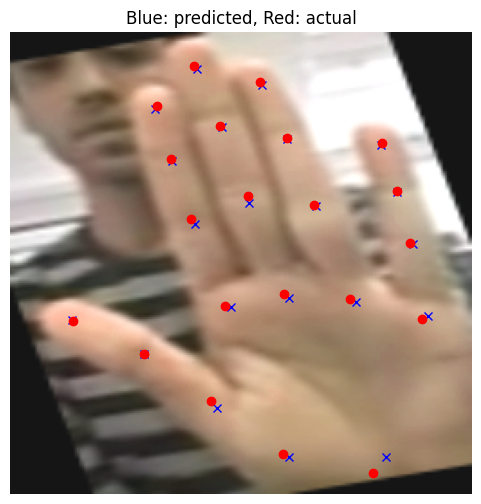

In [41]:
import matplotlib.pyplot as plt

randomIndex = random.randint(0, len(testDataset) - 1)
img_tensor, label_tensor = testDataset[randomIndex]

pred = model(img_tensor.unsqueeze(0).to(device))

img = img_tensor.permute(1, 2, 0).cpu().numpy()
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
h, w, _ = img.shape

# Predicted keypoints from heatmaps (argmax)
hmaps = pred.squeeze(0).cpu()  # (num_kp, Hm, Wm)
num_kp, Hm, Wm = hmaps.shape
for i in range(num_kp):
    hm = hmaps[i].detach().numpy()
    idx = hm.argmax()
    ym = idx // Wm
    xm = idx % Wm
    x_norm = xm / Wm
    y_norm = ym / Hm
    ax.plot(x_norm * w, y_norm * h, 'bx', markersize=6)

# Actual keypoints from label_tensor (x,y,vis triplets)
for k in range(0, len(label_tensor), 3):
    x = label_tensor[k].item()
    y = label_tensor[k + 1].item()
    ax.plot(x * w, y * h, 'ro', markersize=6)

ax.set_title("Blue: predicted, Red: actual")
plt.axis('off')
plt.show()